# 08. 최종 포트폴리오 — GARCH + Black-Litterman

## 전략 요약

| 구성 요소 | 내용 |
|----------|------|
| 변동성 예측 | GARCH(1,1) 1-step ahead (04_VolatilityPrediction 출력) |
| 뷰 행렬 P | 저변동 30% long (시총 비중) / 고변동 30% short (시총 비중) |
| 뷰 수익률 Q | 최적값 — 07_Q_Sensitivity에서 Sharpe 최대 기준 자동 로드 |
| 불확실성 Ω | He-Litterman: Ω = τ·P·Σ·P^T |
| 최적화 | MVO (long-only), 위험회피계수 λ = SPY 초과수익 / σ²_mkt |
| 리밸런싱 | 월별 walk-forward |
| 기간 | 2011-01 ~ 2025-12 (GARCH 시작 시점) |

## 파라미터 표

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `TRAIN_WINDOW` | 60 | 학습 윈도우 (월) |
| `TAU` | 0.1 | BL 스케일 파라미터 |
| `PCT_GROUP` | 0.30 | 저위험/고위험 분류 비율 |
| `Q_OPTIMAL` | 07 자동 로드 | 최적 Q 값 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '08_Final_Portfolio'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 고정 파라미터 ────────────────────────────────────────────
TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2011-01-01'

# ── 최적 Q: 07_Q_Sensitivity 결과에서 자동 로드 ─────────────
STATS_07 = BASE_DIR / 'outputs' / '07_Q_Sensitivity' / 'q_sensitivity_stats.csv'
if STATS_07.exists():
    _s = pd.read_csv(STATS_07, index_col='label')
    _bl = _s.drop(index=['CAPM', 'SPY'], errors='ignore')
    Q_OPTIMAL = float(_bl['sharpe'].idxmax().split('=')[1])
    print(f'07 결과 자동 로드 → Q_OPTIMAL = {Q_OPTIMAL}')
else:
    Q_OPTIMAL = 0.003  # 07 미실행 시 기본값
    print(f'07 결과 없음 → 기본값 사용: Q_OPTIMAL = {Q_OPTIMAL}')
    print('  (07_Q_Sensitivity.ipynb 먼저 실행하면 최적값이 자동 적용됩니다)')

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행하세요'
vol_pred_pivot = (pd.read_csv(PRED_PATH, parse_dates=['date'])
                    .set_index(['date', 'ticker'])['vol_pred']
                    .unstack('ticker'))

print(f'패널: {panel.shape}')
print(f'기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH vol: {vol_pred_pivot.shape}')
print(f'Q_OPTIMAL = {Q_OPTIMAL}  (월 {Q_OPTIMAL*100:.2f}%  |  연 {Q_OPTIMAL*12*100:.1f}%)')

07 결과 자동 로드 → Q_OPTIMAL = 0.003
패널: (108135, 11)
기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH vol: (180, 610)
Q_OPTIMAL = 0.003  (월 0.30%  |  연 3.6%)


# Black-Litterman 구성 함수

In [2]:
def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt):
    """CAPM 균형 기대수익률 π = λ·Σ·w_mkt"""
    lam = spy_excess / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    """P 행렬: 저변동 30% long (시총 비중), 고변동 30% short (시총 비중)"""
    n_group  = max(1, int(len(vol_series) * pct))
    idx_sort = vol_series.sort_values().index
    low_risk  = idx_sort[:n_group]
    high_risk = idx_sort[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    P[low_risk]  =  mcap_series[low_risk]  / mcap_series[low_risk].sum()
    P[high_risk] = -mcap_series[high_risk] / mcap_series[high_risk].sum()
    return P


def compute_omega(P, Sigma, tau):
    """He-Litterman: Ω = τ·P·Σ·P^T"""
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    """μ_BL = π + τΣP^T(PτΣP^T + Ω)^{-1}(Q - Pπ)"""
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M    = float(p @ tSig @ p) + omega
    diff = q - float(p @ pi_v)          # 뷰와 CAPM 간 차이
    return pd.Series(pi_v + tSig @ p * (diff / M), index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    """long-only MVO: max μ^T w - (λ/2) w^T Σ w"""
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    res = minimize(
        fun=lambda w: 0.5 * lam * w @ Sig @ w - w @ mu_,
        x0=np.ones(n) / n,
        jac=lambda w: lam * Sig @ w - mu_,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
    )
    return pd.Series(res.x if res.success else np.ones(n) / n, index=mu.index)


print('BL 함수 정의 완료')
print(f'전략: GARCH vol → P → BL(Q={Q_OPTIMAL}) → MVO')

BL 함수 정의 완료
전략: GARCH vol → P → BL(Q=0.003) → MVO


# Walk-forward 백테스트

매월:
1. GARCH 예측 vol → `build_P()` → 저위험/고위험 분류
2. Ledoit-Wolf 공분산 Σ 추정
3. CAPM 균형 수익률 π 계산
4. `black_litterman()` → μ_BL
5. `optimize_portfolio()` → 비중 w
6. 다음 달 실현수익률로 포트폴리오 수익 계산

In [3]:
bl_records   = []  # 최종 전략
capm_records = []  # 벤치마크 (BL 없이 π만 최적화)
spy_records  = []  # 벤치마크 (SPY)
weight_log   = {}  # 월별 비중 기록 (리밸런싱 참고용)

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'전략: GARCH + Q_FIXED({Q_OPTIMAL})')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_excess  = (spy_series.reindex(train_dates) - rf_series.reindex(train_dates)).mean()
        sigma2_mkt  = spy_series.reindex(train_dates).var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # GARCH vol 적용
        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        month_df['vol_use'] = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        # 유니버스 필터 (학습 데이터 70% 이상 존재하는 종목)
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=month_df.index.tolist())
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)

        # 최종 전략: BL
        mu_BL = black_litterman(pi, Sigma, P, Q_OPTIMAL, omega, TAU)
        w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
        bl_records.append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})
        weight_log[pred_date] = w_bl

        # 벤치마크: CAPM
        w_capm = optimize_portfolio(pi, Sigma, lam)
        capm_records.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_records.append({'date': pred_date, 'ret': r_spy})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

ret_bl   = pd.DataFrame(bl_records).set_index('date')['ret']
ret_capm = pd.DataFrame(capm_records).set_index('date')['ret']
ret_spy  = pd.DataFrame(spy_records).set_index('date')['ret']
weights  = pd.DataFrame(weight_log).T

print(f'\n완료: {len(ret_bl)}개월')

Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
전략: GARCH + Q_FIXED(0.003)
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료: 180개월


# 성과 분석

In [4]:
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf     = rf_monthly.reindex(ret.index).fillna(0)
    excess = ret - rf
    ann_ret  = ret.mean() * 12
    ann_vol  = ret.std() * ANN
    sharpe   = excess.mean() / excess.std() * ANN
    cum      = (1 + ret).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret  = cum.iloc[-1] - 1
    calmar   = ann_ret / abs(mdd) if mdd != 0 else np.nan
    hit_rate = (ret > 0).mean()
    return {
        'label': label,
        '연환산수익률': ann_ret,
        '연환산변동성': ann_vol,
        'Sharpe': sharpe,
        'Calmar': calmar,
        '누적수익률': cum_ret,
        'MDD': mdd,
        '월별승률': hit_rate,
    }

stats_df = pd.DataFrame([
    performance(ret_bl,   f'GARCH+BL (Q={Q_OPTIMAL})'),
    performance(ret_capm, 'CAPM'),
    performance(ret_spy,  'SPY'),
]).set_index('label')

disp = stats_df.copy()
for col in ['연환산수익률', '연환산변동성', '누적수익률', 'MDD', '월별승률']:
    disp[col] = disp[col].map('{:.2%}'.format)
for col in ['Sharpe', 'Calmar']:
    disp[col] = disp[col].map('{:.3f}'.format)

print('=' * 65)
print(f'최종 포트폴리오 성과 ({ret_bl.index[0].date()} ~ {ret_bl.index[-1].date()})')
print('=' * 65)
print(disp.to_string())

# 우위 확인
bl_sharpe   = stats_df.loc[f'GARCH+BL (Q={Q_OPTIMAL})', 'Sharpe']
capm_sharpe = stats_df.loc['CAPM', 'Sharpe']
spy_sharpe  = stats_df.loc['SPY',  'Sharpe']
print()
print(f'vs CAPM: Sharpe {bl_sharpe - capm_sharpe:+.3f}  MDD {stats_df.loc[f"GARCH+BL (Q={Q_OPTIMAL})", "MDD"] - stats_df.loc["CAPM", "MDD"]:+.2%}')
print(f'vs SPY:  Sharpe {bl_sharpe - spy_sharpe:+.3f}')

# 저장
stats_df.to_csv(OUT_DIR / 'final_stats.csv')
ret_bl.to_csv(OUT_DIR / 'final_returns.csv', header=['ret'])
weights.to_csv(OUT_DIR / 'monthly_weights.csv')
print(f'\n저장: {OUT_DIR}/')

최종 포트폴리오 성과 (2011-01-31 ~ 2025-12-31)
                    연환산수익률  연환산변동성 Sharpe Calmar    누적수익률      MDD    월별승률
label                                                                     
GARCH+BL (Q=0.003)  13.50%  11.81%  1.019  0.807  575.70%  -16.73%  67.78%
CAPM                14.21%  14.49%  0.882  0.641  612.78%  -22.17%  67.78%
SPY                 14.03%  14.06%  0.898  0.586     nan%  -23.93%  68.89%

vs CAPM: Sharpe +0.138  MDD +5.44%
vs SPY:  Sharpe +0.121

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/08_Final_Portfolio/


# 시각화

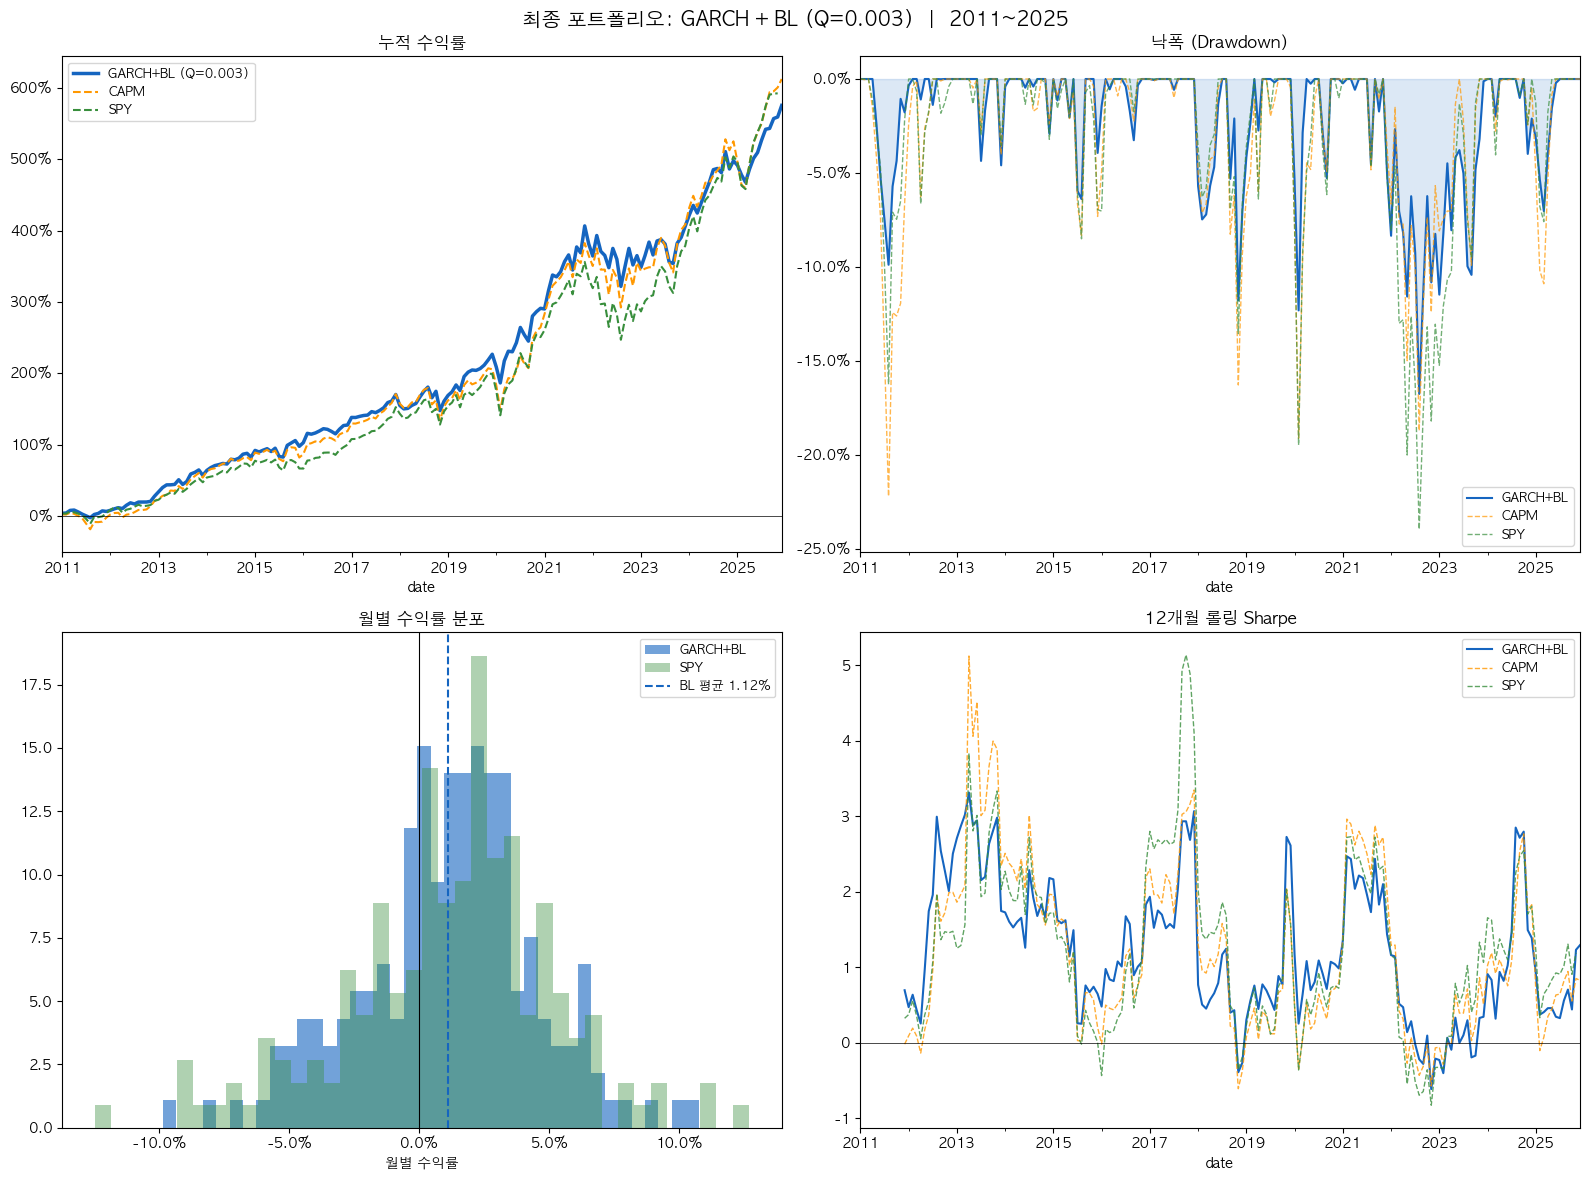

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'최종 포트폴리오: GARCH + BL (Q={Q_OPTIMAL})  |  2011~2025',
             fontsize=14, fontweight='bold')

# ① 누적 수익률
ax = axes[0, 0]
((1 + ret_bl).cumprod()   - 1).plot(ax=ax, label=f'GARCH+BL (Q={Q_OPTIMAL})',
                                     color='#1565C0', linewidth=2.5)
((1 + ret_capm).cumprod() - 1).plot(ax=ax, label='CAPM',
                                     color='#FF9800', linestyle='--', linewidth=1.5)
((1 + ret_spy).cumprod()  - 1).plot(ax=ax, label='SPY',
                                     color='#388E3C', linestyle='--', linewidth=1.5)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

# ② 낙폭 (Drawdown)
ax = axes[0, 1]
def drawdown(ret):
    cum = (1 + ret).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

drawdown(ret_bl).plot(ax=ax,   label=f'GARCH+BL', color='#1565C0', linewidth=1.5)
drawdown(ret_capm).plot(ax=ax, label='CAPM',      color='#FF9800', linestyle='--', linewidth=1.0, alpha=0.7)
drawdown(ret_spy).plot(ax=ax,  label='SPY',       color='#388E3C', linestyle='--', linewidth=1.0, alpha=0.7)
ax.fill_between(ret_bl.index, drawdown(ret_bl), 0, alpha=0.15, color='#1565C0')
ax.set_title('낙폭 (Drawdown)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

# ③ 월별 수익률 분포
ax = axes[1, 0]
ax.hist(ret_bl,   bins=40, alpha=0.6, color='#1565C0', label=f'GARCH+BL', density=True)
ax.hist(ret_spy,  bins=40, alpha=0.4, color='#388E3C', label='SPY',        density=True)
ax.axvline(ret_bl.mean(),  color='#1565C0', linestyle='--', linewidth=1.5,
           label=f'BL 평균 {ret_bl.mean():.2%}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('월별 수익률 분포')
ax.set_xlabel('월별 수익률')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

# ④ 롤링 Sharpe (12개월)
ax = axes[1, 1]
rf_roll = rf_monthly.reindex(ret_bl.index).fillna(0)

def rolling_sharpe(ret, rf, window=12):
    exc = ret - rf
    return exc.rolling(window).mean() / exc.rolling(window).std() * np.sqrt(12)

rolling_sharpe(ret_bl,   rf_roll).plot(ax=ax, label='GARCH+BL', color='#1565C0', linewidth=1.5)
rolling_sharpe(ret_capm, rf_monthly.reindex(ret_capm.index).fillna(0)).plot(
    ax=ax, label='CAPM', color='#FF9800', linestyle='--', linewidth=1.0, alpha=0.8)
rolling_sharpe(ret_spy,  rf_monthly.reindex(ret_spy.index).fillna(0)).plot(
    ax=ax, label='SPY',  color='#388E3C', linestyle='--', linewidth=1.0, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('12개월 롤링 Sharpe')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'final_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

# 월별 비중 분석

리밸런싱 구조 확인: 종목 집중도, 상위 보유 종목, 유효 종목 수

In [6]:
# 월평균 유효 종목 수 (비중 > 0.1%)
n_holdings   = (weights > 0.001).sum(axis=1)
top1_conc    = weights.max(axis=1)           # 최대 단일 종목 비중
top5_conc    = weights.apply(lambda r: r.nlargest(5).sum(), axis=1)  # 상위 5종목 합산

print('월별 포트폴리오 구조 (평균)')
print(f'  유효 종목 수 (비중 > 0.1%): {n_holdings.mean():.1f}개  (min {n_holdings.min()} / max {n_holdings.max()})')
print(f'  최대 단일 종목 비중:        {top1_conc.mean():.2%}')
print(f'  상위 5종목 합산 비중:       {top5_conc.mean():.2%}')

# 전체 기간 평균 비중 상위 10 종목
mean_weights = weights.mean().sort_values(ascending=False)
print()
print('전체 기간 평균 비중 상위 10 종목:')
print(mean_weights.head(10).map('{:.3%}'.format).to_string())

# 저장된 파일 목록
print()
print('저장된 파일:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}')

월별 포트폴리오 구조 (평균)
  유효 종목 수 (비중 > 0.1%): 105.7개  (min 42 / max 197)
  최대 단일 종목 비중:        10.53%
  상위 5종목 합산 비중:       26.54%

전체 기간 평균 비중 상위 10 종목:
ticker
MSFT     6.051%
BRK-B    4.214%
GE       4.183%
JNJ      2.826%
PG       2.580%
AAPL     2.191%
KO       2.154%
XOM      2.096%
V        2.082%
PEP      1.905%

저장된 파일:
  final_portfolio.png
  final_returns.csv
  final_stats.csv
  monthly_weights.csv
